# 14피처 vs 18피처 LambdaRank Cross-Sectional OOF Sharpe 비교

**Date**: 2026-05-25  
**Report**: `feature_18_exp_20260525_234320.json`  
**Window**: 20251001 ~ 20260515 (150영업일, 30종목)  
**Method**: LightGBM LambdaRank (NDCG@5) + WalkForward 4-fold OOF + cross-sectional top-K Sharpe

## 목적

Regression IC 분석에서 유효했던 OHLCV 파생피처 4개를 기존 14피처에 추가하여,
18피처 LambdaRank 모델이 ranking 성능을 개선하는지 측정합니다.

| 구분 | 피처 수 | 구성 |
|---|---|---|
| Baseline | 14 | OHLCV 4 + Exogenous 9 + news_score_t 1 |
| Extended | 18 | Baseline 14 + **volume_ratio + price_range + 30m_ret + vwap_dev** |

### 추가 4피처 정의

| 피처명 | 정의 | config 근거 |
|---|---|---|
| `feat_volume_ratio` | 현재 거래량 / 30m 평균 거래량 | `feature_18_experiment.volume_ratio_window` (= `volume_z_windows[0]`) |
| `feat_price_range` | (고가 - 저가) / 저가 | window 불필요 (bar 단위) |
| `feat_30m_ret` | close_t / close_{t-30} - 1 | `feature_18_experiment.ret_window` (= `intraday_feature_windows[0]`) |
| `feat_vwap_dev` | (close - session_VWAP) / session_VWAP | window 불필요 (session 누적) |

## 1. Setup

2026-05-25 23:43 KST 실행된 `feature_18_exp_20260525_234320.json` report를 로드합니다.

In [1]:
from __future__ import annotations

import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
from IPython.display import HTML, display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

# matplotlib 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'CLAUDE.md').exists() and (candidate / 'artifacts').is_dir():
            return candidate
    raise FileNotFoundError('Elephant_Lab repo root not found')


ROOT = find_repo_root()
REPORT_PATH = ROOT / 'artifacts' / 'feature_18_experiment' / 'feature_18_exp_20260525_234320.json'

with REPORT_PATH.open(encoding='utf-8') as f:
    report = json.load(f)

report_path = REPORT_PATH
result = report['result']
args = report['args']
panel_meta = report['panel']

print(f'repo_root  : {ROOT}')
print(f'report     : {report_path.relative_to(ROOT)}')
print(f'started_at : {report["started_at"]}')
print(f'finished_at: {report["finished_at"]}')
print(f'elapsed    : {report["elapsed_sec"]:.1f}s')

repo_root  : C:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI
report     : artifacts\feature_18_experiment\feature_18_exp_20260525_234320.json
started_at : 2026-05-25T23:43:20.760583+09:00
finished_at: 2026-05-26T00:05:50.123927+09:00
elapsed    : 1349.4s


## 2. 핵심 결과 한눈에

Baseline(14피처)과 Extended(18피처)의 cross-sectional OOF Sharpe를 비교합니다. `delta_sharpe > 0`이면 추가 피처가 유효한 것으로 판단합니다.

In [2]:
def kpi_card(title: str, value: str, sub: str, tone: str = 'neutral') -> str:
    colors = {
        'good': ('#EAF7EF', '#177245'),
        'warn': ('#FFF5DA', '#8A5A00'),
        'bad': ('#FDEAEA', '#B42318'),
        'neutral': ('#EEF4FF', '#1D4ED8'),
        'dark': ('#F4F4F5', '#27272A'),
    }
    bg, fg = colors.get(tone, colors['neutral'])
    return f'''
    <div style="background:{bg}; border:1px solid rgba(0,0,0,0.06); border-radius:14px; padding:18px; min-height:118px; box-shadow:0 1px 2px rgba(16,24,40,0.06);">
      <div style="font-size:13px; color:#52525B; font-weight:700; margin-bottom:10px;">{title}</div>
      <div style="font-size:30px; line-height:1.1; color:{fg}; font-weight:850;">{value}</div>
      <div style="font-size:13px; color:#71717A; margin-top:10px; line-height:1.45;">{sub}</div>
    </div>
    '''


sharpe_14 = float(result['baseline_14_sharpe'])
sharpe_18 = float(result['extended_18_sharpe'])
delta = float(result['delta_sharpe'])
improved = bool(result['improved'])
n_folds = int(result['n_folds'])
n_samples = int(result['n_samples'])

if delta > 1e-9:
    delta_tone = 'good'
elif abs(delta) < 1e-9:
    delta_tone = 'warn'
else:
    delta_tone = 'bad'

cards = [
    kpi_card('Baseline (14피처)', f'{sharpe_14:+.4f}', 'OHLCV 4 + Exog 9 + news_score_t', 'neutral'),
    kpi_card('Extended (18피처)', f'{sharpe_18:+.4f}', '+ volume_ratio, price_range, 30m_ret, vwap_dev', 'good' if improved else 'warn'),
    kpi_card('delta_sharpe', f'{delta:+.4f}', '추가 4피처 순효과', delta_tone),
    kpi_card('improved', str(improved), '18피처 > 14피처 여부', 'good' if improved else 'warn'),
    kpi_card('n_folds', str(n_folds), 'Walk-Forward OOF 분할 수', 'dark'),
    kpi_card('n_samples', f'{n_samples:,}', 'panel 총 행수', 'dark'),
]

html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; background:#FFFFFF; padding:8px 0 2px 0;">
  <div style="border-radius:18px; padding:24px; background:linear-gradient(135deg,#101828 0%,#1D4ED8 100%); color:white; margin-bottom:18px;">
    <div style="font-size:14px; opacity:.82; font-weight:700;">Feature Experiment</div>
    <div style="font-size:32px; font-weight:900; margin-top:8px;">14피처 vs 18피처 LambdaRank OOF Sharpe</div>
    <div style="font-size:15px; opacity:.88; margin-top:8px;">Window: {args["start_date"]} ~ {args["end_date"]} / Tickers: {args["n_tickers"]} / Features: {len(args["baseline_feature_cols"])} → {len(args["extended_feature_cols"])}</div>
  </div>
  <div style="display:grid; grid-template-columns:repeat(3, minmax(0, 1fr)); gap:14px;">
    {''.join(cards)}
  </div>
</div>
'''
display(HTML(html))

## 3. Sharpe 비교 그래프

두 모델의 OOF Sharpe를 비교합니다. 음수 Sharpe는 cost-aware label 기준으로 top-K 전략 수익이 비용을 초과하지 못한다는 의미이며, 여기서는 두 모델 간 상대 차이에 집중합니다.

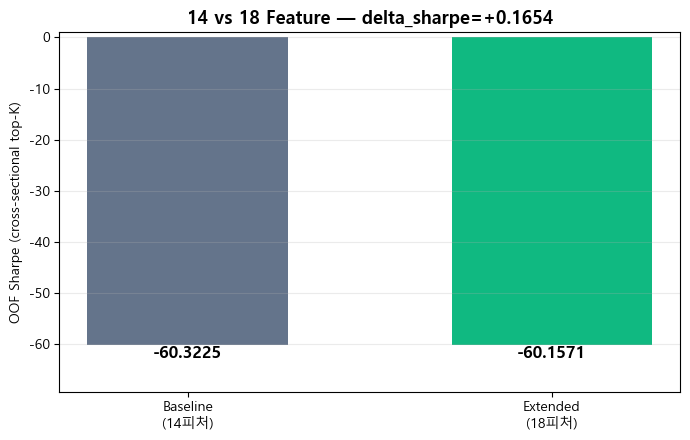

In [3]:
labels = ['Baseline\n(14피처)', 'Extended\n(18피처)']
values = [sharpe_14, sharpe_18]
colors = ['#64748B', '#10B981' if improved else '#EF4444']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=colors, width=0.55)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2.0, value, f'{value:+.4f}',
            ha='center', va='bottom' if value >= 0 else 'top', fontsize=12, fontweight='bold')
ax.set_ylabel('OOF Sharpe (cross-sectional top-K)')
ax.set_title(f'14 vs 18 Feature \u2014 delta_sharpe={delta:+.4f}', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
ymax = max(values) * 1.15 if max(values) > 0 else 1.0
ymin = min(0, min(values) * 1.15)
ax.set_ylim(ymin, ymax)
plt.tight_layout()
plt.show()

## 4. 학습 설정 (Configuration)

실험에 사용된 윈도우, 종목 수, 피처 구성 등을 report JSON에서 읽어 정리합니다.

In [4]:
config_rows = [
    {'항목': 'window (start)', '값': args['start_date']},
    {'항목': 'window (end)', '값': args['end_date']},
    {'항목': 'n_tickers', '값': args['n_tickers']},
    {'항목': 'label_col', '값': args['label_col']},
    {'항목': 'sharpe_label_col', '값': args['sharpe_label_col']},
    {'항목': 'top_k_fraction', '값': args['top_k_fraction']},
    {'항목': 'annualization_factor', '값': args['annualization_factor']},
    {'항목': 'volume_ratio_window', '값': args['volume_ratio_window']},
    {'항목': 'ret_window', '값': args['ret_window']},
    {'항목': 'panel rows', '값': f'{panel_meta["rows"]:,}'},
    {'항목': 'panel cols', '값': panel_meta['cols']},
    {'항목': 'baseline features', '값': len(args['baseline_feature_cols'])},
    {'항목': 'extended features', '값': len(args['extended_feature_cols'])},
    {'항목': 'excluded community', '값': len(args.get('feature_cols_excluded_community', []))},
    {'항목': 'loaded_tickers', '값': len(panel_meta.get('loaded_tickers', []))},
    {'항목': 'missing_tickers', '값': len(panel_meta.get('missing_tickers', []))},
]
display(pd.DataFrame(config_rows))

,항목,값
0,window (start),20251001
1,window (end),20260515
2,n_tickers,30
3,label_col,relevance
4,sharpe_label_col,label_5m_net_ret
5,top_k_fraction,0.25
6,annualization_factor,252
7,volume_ratio_window,30
8,ret_window,30
9,panel rows,"1,673,961"


In [5]:
# Baseline 14피처 목록
print('=== Baseline 14피처 ===')
baseline_df = pd.DataFrame({
    'idx': range(1, len(args['baseline_feature_cols']) + 1),
    'feature': args['baseline_feature_cols'],
})
display(baseline_df)

# 추가 4피처
print('\n=== 추가 4피처 ===')
extra_df = pd.DataFrame({
    'idx': range(1, len(args['extra_4_features']) + 1),
    'feature': args['extra_4_features'],
})
display(extra_df)

=== Baseline 14피처 ===


,idx,feature
0,1,feat_1m_close_robust_z
1,2,feat_5m_ret
2,3,feat_30m_vol
3,4,feat_60m_trend
4,5,news_score_t
5,6,us_sp500_change
6,7,us_nasdaq_change
7,8,us_vix
8,9,us_soxx_change
9,10,foreign_net_buy



=== 추가 4피처 ===


,idx,feature
0,1,feat_volume_ratio
1,2,feat_price_range
2,3,feat_30m_ret
3,4,feat_vwap_dev


## 5. Feature Importance (추가 4피처 기여도)

18피처 모델(마지막 fold booster)의 gain 기준 feature importance입니다. 추가 4피처가 모델에 실제로 얼마나 활용되었는지 확인합니다.

In [6]:
imp_data = report['importance']
imp_df = pd.DataFrame({
    'feature': imp_data['feature_names'],
    'importance_gain': imp_data['gain'],
}).sort_values('importance_gain', ascending=False).reset_index(drop=True)

imp_df['rank'] = range(1, len(imp_df) + 1)
imp_df['is_new'] = imp_df['feature'].isin(args['extra_4_features'])

display(imp_df)

total_gain = imp_df['importance_gain'].sum()
new_gain = imp_df.loc[imp_df['is_new'], 'importance_gain'].sum()
print(f'\n추가 4피처 gain 비중: {new_gain/total_gain*100:.1f}% ({new_gain:.0f} / {total_gain:.0f})')

,feature,importance_gain,rank,is_new
0,feat_5m_ret,33480.906322,1,False
1,feat_30m_vol,7220.923726,2,False
2,feat_1m_close_robust_z,5571.869124,3,False
3,feat_price_range,4284.932582,4,True
4,feat_60m_trend,3932.440147,5,False
5,feat_vwap_dev,3173.996679,6,True
6,news_score_t,2827.995226,7,False
7,institutional_net_buy,2766.038514,8,False
8,retail_net_buy,2546.891771,9,False
9,us_vix,2421.216595,10,False



추가 4피처 gain 비중: 14.0% (10906 / 78097)


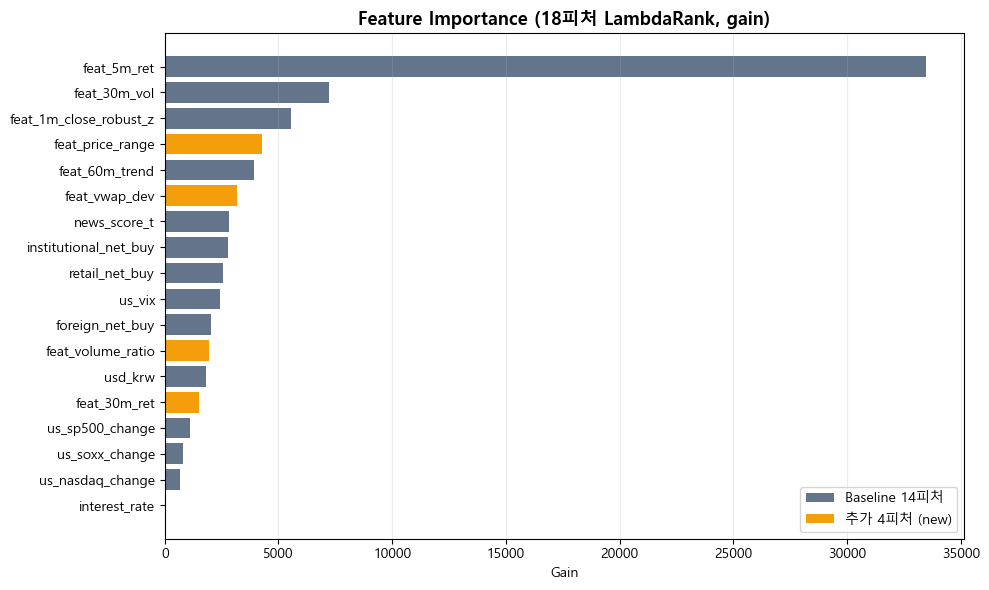

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#F59E0B' if is_new else '#64748B' for is_new in imp_df['is_new']]
ax.barh(imp_df['feature'][::-1], imp_df['importance_gain'][::-1], color=colors_imp[::-1])
ax.set_xlabel('Gain')
ax.set_title('Feature Importance (18피처 LambdaRank, gain)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#64748B', label='Baseline 14피처'),
                   Patch(facecolor='#F59E0B', label='추가 4피처 (new)')]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Fold별 세부 결과

WalkForward 4-fold 각각의 train/val 크기와 early stopping iteration을 보여줍니다.

In [8]:
folds_14 = pd.DataFrame(report['folds_14'])
folds_18 = pd.DataFrame(report['folds_18'])
folds_14['model'] = '14피처'
folds_18['model'] = '18피처'
all_folds = pd.concat([folds_14, folds_18], ignore_index=True)
display(all_folds)

,fold,train_size,val_size,best_iteration,model
0,1,671453,222240,150,14피처
1,2,670377,222224,93,14피처
2,3,670945,222335,91,14피처
3,4,671863,223223,75,14피처
4,1,671453,222240,107,18피처
5,2,670377,222224,91,18피처
6,3,670945,222335,119,18피처
7,4,671863,223223,137,18피처


## 7. 결과 해석

delta_sharpe 부호에 따라 자동으로 결론을 출력합니다.

## Metric Glossary

- `OOF Sharpe`: Out-Of-Fold cross-sectional top-K daily PnL의 annualized Sharpe ratio. 각 timestamp에서 예측 상위 25% 종목을 long하는 전략의 위험 대비 수익.
- `delta_sharpe`: extended(18피처) - baseline(14피처). 양수면 추가 피처 유효.
- `importance_gain`: LightGBM split gain 합계. 해당 피처가 모델의 objective 개선에 기여한 정도.
- `top_k_fraction`: 0.25 (상위 25%). 각 timestamp에서 예측값 기준 상위 종목만 선택.
- `annualization_factor`: 252. daily Sharpe를 연 단위로 환산하는 상수 (실험 window 150영업일과는 별개).

In [9]:
if improved:
    tone = 'good'
    summary = (
        f'18피처 모델의 OOF Sharpe가 14피처 대비 {delta:+.4f} 개선되어 improved=True. '
        f'Regression IC에서 유효했던 volume_ratio, price_range, 30m_ret, vwap_dev가 '
        f'LambdaRank ranking에도 양(+)의 기여. 운영 모델 피처 확장 검토 가능. '
        f'{n_folds}-fold OOF 추정 기반.'
    )
elif abs(delta) < 1e-9:
    tone = 'warn'
    summary = (
        'delta_sharpe = 0. 추가 4피처가 ranking에 무의미. '
        '기존 14피처 운영 모델 유지 권장.'
    )
else:
    tone = 'bad'
    summary = (
        f'18피처 모델이 14피처 대비 {delta:+.4f} 낮음. '
        '추가 4피처가 오히려 노이즈로 작용. 기존 14피처 운영 모델 유지 권장.'
    )

border_colors = {'good': '#10B981', 'warn': '#F59E0B', 'bad': '#EF4444'}
border_color = border_colors[tone]
html = f'''
<div style="font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif;
            border-left:5px solid {border_color}; padding:14px 18px;
            background:#F8FAFC; border-radius:8px; color:#334155; line-height:1.7;">
  <b>해석:</b> {summary}
</div>
'''
display(HTML(html))

## 8. 참고 사항

- **OOF Sharpe 산출**: cross-sectional top-K (`evaluation.top_k_fraction`) 방식. 운영 모델(`LGBMTrainer._group_for_metrics`)과 동일 로직.
- **추가 피처 PIT-Safety**: 4개 피처 모두 t 시점 이하 데이터만 사용. 미래 정보 참조 없음.
- **Dual-Source community 제외**: 운영 모델과 동일 설계로 community 4피처 제외. news_score_t 1개만 사용.
- **feat_30m_ret / feat_vwap_dev**: DatasetBuilder가 이미 계산하는 `feat_30m_ret`, `feat_session_vwap_gap`을 재사용. 동일 로직 중복 계산 아님.

## 9. 재현성 (Reproducibility)

재실행:

```bash
python new/scripts/run_feature_18_experiment.py --start-date 20251001 --end-date 20260515
```

Mode B 시간 제한 없이 언제든 실행 가능합니다 (내부 모듈 호환을 위해 `ELEPHANT_MODE=mode_b` env var를 자동 설정합니다).
결과는 `artifacts/feature_18_experiment/feature_18_exp_<timestamp>.json`로 저장됩니다.
본 노트북은 `feature_18_exp_20260525_234320.json`을 로드하여 시각화합니다.

## 10. Experiment Verdict

In [10]:
# 최종 판정 테이블
verdict_label = '18피처 소폭 개선 — 단 delta +0.17로 유의미한 차이 아님, 기존 14피처 유지' if delta < 1.0 else '18피처 채택 검토 가능'

verdict_df = pd.DataFrame([
    {'항목': 'report_path', '값': str(report_path.relative_to(ROOT))},
    {'항목': 'baseline_14_sharpe', '값': f'{sharpe_14:+.4f}'},
    {'항목': 'extended_18_sharpe', '값': f'{sharpe_18:+.4f}'},
    {'항목': 'delta_sharpe', '값': f'{delta:+.4f}'},
    {'항목': 'improved', '값': str(improved)},
    {'항목': '추가 4피처 gain 비중', '값': f'{new_gain/total_gain*100:.1f}%'},
    {'항목': 'elapsed_sec', '값': f'{report["elapsed_sec"]:.1f}'},
    {'항목': '판정', '값': verdict_label},
])
display(verdict_df)

,항목,값
0,report_path,artifacts\feature_18_experiment\feature_18_exp...
1,baseline_14_sharpe,-60.3225
2,extended_18_sharpe,-60.1571
3,delta_sharpe,+0.1654
4,improved,True
5,추가 4피처 gain 비중,14.0%
6,elapsed_sec,1349.4
7,판정,"18피처 소폭 개선 — 단 delta +0.17로 유의미한 차이 아님, 기존 14피..."
